# 04 — Cluster Feature Experiment

This notebook tests whether **KMeans-derived team-profile features add predictive value** to the model + feature-set combinations shortlisted in `03_model_feature_selection.ipynb`.

The experiment is deliberately paired to assess whether clustering actually helps:

> **same model + same selected feature set**  
> versus  
> **same model + same selected feature set + cluster-distance features**

### Objectives

1. Load the **model-specific shortlist from 03** rather than choosing models or feature sets again.

2. Build KMeans team profiles from a small set of interpretable offense, pitching, and fielding measures.

3. Test a small sensitivity range of **K = 4, 6, and 8 clusters** instead of assuming the old project choice of `K=6` is automatically best.

4. Fit the scaler and KMeans **inside each CV training fold** so the validation fold does not influence the cluster centroids.

5. Compare baseline MAE against cluster-augmented MAE using the **same 5-fold GroupKFold by season** used in 03.

6. Decide whether cluster features are worth carrying into final model training.

### How this notebook does it

For every model + feature-set combination shortlisted in 03:

- run the original configuration again as the **baseline**;
- add distances to **4 KMeans centroids** and evaluate;
- add distances to **6 KMeans centroids** and evaluate;
- add distances to **8 KMeans centroids** and evaluate;
- compare mean MAE, fold variation, and how many folds improved.

Only **distance-to-centroid features** are added.

We do not use the raw KMeans label because cluster IDs such as `0`, `1`, `2` are arbitrary categories. Treating them as ordinary numeric values would introduce a false ordering, especially for Ridge and ElasticNet.

### Outputs

Written to `outputs/cluster_experiment/`:

- `04_cluster_feature_results.csv`  
  Full baseline and K=4/6/8 results for every shortlisted model configuration.

- `04_cluster_feature_summary.csv`  
  Best cluster result per model, its change versus baseline, and fold-level improvement count.

### Decision made at the end of this notebook

Cluster features are carried forward **only if they improve the shortlisted configuration in a useful and reasonably stable way**.

This notebook does **not** tune the final model, test ensembles, or create the submission.


## 1. Setup and load the canonical inputs

04 has two upstream dependencies:

- `data/processed/train_fe.csv` and `pred_fe.csv` from **02**;
- `outputs/model_selection/03_model_shortlist.csv` from **03**.

We do not create another permanent processed dataset here. Cluster features are experimental and are generated inside each CV fold.

In [8]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from moneyball import project_config as cfg
from moneyball import model_factory as mf
from moneyball import feature_sets as fs


cfg.configure_notebook()
cfg.ensure_project_dirs()

TRAIN_FE_PATH  = cfg.TRAIN_FE_PATH
PRED_FE_PATH   = cfg.PRED_FE_PATH

SHORTLIST_PATH = cfg.MODEL_SHORTLIST_PATH

RESULT_PATH    = cfg.CLUSTER_RESULT_PATH
SUMMARY_PATH   = cfg.CLUSTER_SUMMARY_PATH

print(f"Train FE   : {TRAIN_FE_PATH}")
print(f"Shortlist  : {SHORTLIST_PATH}")
print(f"Results dir: {RESULT_PATH}")

Train FE   : /home/shpang/devs/ntu/projects/baseball_v2/data/processed/train_fe.csv
Shortlist  : /home/shpang/devs/ntu/projects/baseball_v2/outputs/model_selection/03_model_shortlist.csv
Results dir: /home/shpang/devs/ntu/projects/baseball_v2/outputs/cluster_experiment/04_cluster_feature_results.csv


In [3]:
train_fe = pd.read_csv(TRAIN_FE_PATH)
pred_fe = pd.read_csv(PRED_FE_PATH)

if not SHORTLIST_PATH.exists():
    raise FileNotFoundError(
        "03_model_shortlist.csv was not found. "
        "Run 03_model_feature_selection.ipynb first."
    )

shortlist = pd.read_csv(SHORTLIST_PATH)

required_shortlist_cols = {"model", "feature_set"}
missing = required_shortlist_cols - set(shortlist.columns)
if missing:
    raise ValueError(
        f"03 shortlist is missing required columns: {sorted(missing)}"
    )

# Rebuild the standard feature sets from the single shared definition used in 03.
FEATURE_SETS = fs.get_candidate_feature_sets(train_fe)
fs.validate_feature_sets(train_fe, pred_fe, FEATURE_SETS)

print("Train shape :", train_fe.shape)
print("Pred shape  :", pred_fe.shape)
print("\nShortlisted configurations from 03:")
display(shortlist[["model", "feature_set", "n_features", "mae_mean", "mae_std"]])

Train shape : (1812, 78)
Pred shape  : (453, 76)

Shortlisted configurations from 03:


,model,feature_set,n_features,mae_mean,mae_std
0,elasticnet,all_domain_raw,72,2.727792,0.089080
1,ridge,all_domain_raw,72,2.729300,0.101873
2,hgb,all_domain_raw,72,3.070202,0.065738


## 2. Define the team-profile features used by KMeans

The clustering inputs describe **how a team plays**, not simply repeat every model feature.

### Decision

Use a small profile spanning offense, run prevention, pitching, and fielding:

- `core_R_pg` — runs scored per game;
- `core_RA_pg` — runs allowed per game;
- `bat_OPS_approx` — overall batting production;
- `bat_ISO` — power;
- `pitch_WHIP` — baserunners allowed per inning;
- `pitch_K_BB` — pitching command / dominance;
- `field_FP` — fielding percentage.

### Reasoning

The old cluster notebook used a mixture of older feature names and raw-volume measures and hard-coded `K=6`.

Here the aim is different: create an interpretable **team archetype representation** from normalized performance characteristics. KMeans then converts that profile into distances from several team archetypes.

We deliberately avoid `target_W`, win percentage, or any target-derived quantity.

In [4]:
CLUSTER_PROFILE_FEATURES = [
    "core_R_pg",
    "core_RA_pg",
    "bat_OPS_approx",
    "bat_ISO",
    "pitch_WHIP",
    "pitch_K_BB",
    "field_FP",
]

missing_train = sorted(
    set(CLUSTER_PROFILE_FEATURES) - set(train_fe.columns)
)
missing_pred = sorted(
    set(CLUSTER_PROFILE_FEATURES) - set(pred_fe.columns)
)

assert not missing_train, (
    f"Cluster profile features missing from train: {missing_train}"
)
assert not missing_pred, (
    f"Cluster profile features missing from prediction: {missing_pred}"
)

print("Cluster profile features:")
for feature in CLUSTER_PROFILE_FEATURES:
    print(f"  - {feature}")

Cluster profile features:
  - core_R_pg
  - core_RA_pg
  - bat_OPS_approx
  - bat_ISO
  - pitch_WHIP
  - pitch_K_BB
  - field_FP


## 3. Cross-validation design

We use the same outer validation design as 03:

- **5-fold GroupKFold**
- grouped by `meta_yearID`
- target = `target_W`
- metric = **MAE in wins**

### Important leakage fix

For every fold:
1. fit the cluster imputer on the training fold only;
2. fit the cluster scaler on the training fold only;
3. fit KMeans on the training fold only;
4. transform both training and validation rows using those fitted objects;
5. train the prediction model;
6. score the untouched validation fold.

This keeps the cluster experiment inside the CV boundary.

In [5]:
TARGET_COL = "target_W"
GROUP_COL = "meta_yearID"
N_SPLITS = 5

K_VALUES = [4, 6, 8]
RANDOM_STATE = 42

groups = train_fe[GROUP_COL]
cv = GroupKFold(n_splits=N_SPLITS)

print("Target      :", TARGET_COL)
print("Group       :", GROUP_COL)
print("CV folds    :", N_SPLITS)
print("K values    :", K_VALUES)

Target      : target_W
Group       : meta_yearID
CV folds    : 5
K values    : [4, 6, 8]


## 4. Recreate the same candidate model definitions used in 03

Reproduce whichever models were shortlisted in 03.

The settings stay deliberately light because we still want to isolate the effect of the **cluster features**, not mix that effect with a new round of tuning.

In [9]:
# Reuse the exact same model definitions from 03.
# 04 is testing the effect of cluster features, so model settings stay fixed.

MODEL_FACTORIES = mf.MODEL_FACTORIES

unknown_models = sorted(
    set(shortlist["model"]) - set(MODEL_FACTORIES)
)
assert not unknown_models, (
    f"Shortlist contains unsupported models: {unknown_models}"
)

print("Models required by 03 shortlist:", list(shortlist["model"]))

Models required by 03 shortlist: ['elasticnet', 'ridge', 'hgb']


## 5. Cluster transformation helper

This helper is intentionally kept in this notebook for now.

If cluster features survive this experiment and become part of the final model, we can then promote the transformation into a reusable `.py` module. If clustering does not help, there is no reason to turn an abandoned experiment into permanent project infrastructure.

In [11]:
def make_cluster_distances(
    X_train_profile,
    X_valid_profile,
    *,
    n_clusters,
    random_state=42,
):
    """Fit cluster preprocessing on one training fold and return distances.

    Nothing from the validation fold is used to estimate medians, scaling
    parameters, or cluster centroids.
    """

    # Median imputation is fitted on the training fold only.
    imputer = SimpleImputer(strategy="median")
    train_imputed = imputer.fit_transform(X_train_profile)
    valid_imputed = imputer.transform(X_valid_profile)

    # KMeans is distance-based, so profile features must share a common scale.
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_imputed)
    valid_scaled = scaler.transform(valid_imputed)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=20,
    )
    kmeans.fit(train_scaled)

    train_dist = kmeans.transform(train_scaled)
    valid_dist = kmeans.transform(valid_scaled)

    dist_cols = [
        f"cl_dist_k{n_clusters}_c{i}"
        for i in range(n_clusters)
    ]

    train_dist = pd.DataFrame(
        train_dist,
        columns=dist_cols,
        index=X_train_profile.index,
    )
    valid_dist = pd.DataFrame(
        valid_dist,
        columns=dist_cols,
        index=X_valid_profile.index,
    )

    return train_dist, valid_dist

## 6. Evaluate baseline vs cluster-augmented configurations

For each shortlisted model:

1. use the exact feature set selected for that model in 03;
2. score the original configuration again;
3. score the same model after adding KMeans-distance features for K=4, 6, and 8.

Because every version uses the same folds, the fold-level MAEs can be compared directly.

In [12]:
def evaluate_configuration(
    *,
    model_factory,
    base_features,
    n_clusters=None,
):
    """Evaluate one shortlisted configuration with or without clustering."""

    y = train_fe[TARGET_COL].astype(float)
    fold_mae = []

    for train_idx, valid_idx in cv.split(
        train_fe,
        y,
        groups=groups,
    ):
        train_fold = train_fe.iloc[train_idx]
        valid_fold = train_fe.iloc[valid_idx]

        X_train = train_fold[base_features].copy()
        X_valid = valid_fold[base_features].copy()

        if n_clusters is not None:
            train_dist, valid_dist = make_cluster_distances(
                train_fold[CLUSTER_PROFILE_FEATURES],
                valid_fold[CLUSTER_PROFILE_FEATURES],
                n_clusters=n_clusters,
                random_state=RANDOM_STATE,
            )

            # Join by original row index so cluster distances remain aligned
            # with the model features.
            X_train = X_train.join(train_dist)
            X_valid = X_valid.join(valid_dist)

        model = model_factory()

        model.fit(
            X_train,
            y.iloc[train_idx],
        )

        prediction = model.predict(X_valid)

        fold_mae.append(
            mean_absolute_error(
                y.iloc[valid_idx],
                prediction,
            )
        )

    return {
        "mae_mean": float(np.mean(fold_mae)),
        "mae_std": float(np.std(fold_mae)),
        "fold_mae": fold_mae,
    }

In [13]:
rows = []

with warnings.catch_warnings():
    warnings.simplefilter("once", ConvergenceWarning)

    for _, shortlist_row in shortlist.iterrows():
        model_name = shortlist_row["model"]
        feature_set_name = shortlist_row["feature_set"]

        model_factory = MODEL_FACTORIES[model_name]
        base_features = FEATURE_SETS[feature_set_name]

        variants = [("baseline", None)] + [
            (f"cluster_k{k}", k)
            for k in K_VALUES
        ]

        for variant_name, n_clusters in variants:
            started = time.perf_counter()

            result = evaluate_configuration(
                model_factory=model_factory,
                base_features=base_features,
                n_clusters=n_clusters,
            )

            elapsed = time.perf_counter() - started

            row = {
                "model": model_name,
                "feature_set": feature_set_name,
                "variant": variant_name,
                "n_clusters": n_clusters,
                "base_n_features": len(base_features),
                "total_n_features": (
                    len(base_features)
                    if n_clusters is None
                    else len(base_features) + n_clusters
                ),
                "mae_mean": result["mae_mean"],
                "mae_std": result["mae_std"],
                "seconds": elapsed,
            }

            for fold_no, fold_value in enumerate(
                result["fold_mae"],
                start=1,
            ):
                row[f"fold_{fold_no}_mae"] = fold_value

            rows.append(row)

            print(
                f"{model_name:14s} | "
                f"{feature_set_name:18s} | "
                f"{variant_name:10s} | "
                f"MAE {result['mae_mean']:.4f} "
                f"± {result['mae_std']:.4f}"
            )

results = (
    pd.DataFrame(rows)
    .sort_values(
        ["model", "mae_mean", "mae_std"],
        ascending=[True, True, True],
    )
    .reset_index(drop=True)
)

results.to_csv(RESULT_PATH, index=False)

print(f"\nSaved full results to: {RESULT_PATH}")
display(results)

elasticnet     | all_domain_raw     | baseline   | MAE 2.7278 ± 0.0891
elasticnet     | all_domain_raw     | cluster_k4 | MAE 2.7351 ± 0.0942
elasticnet     | all_domain_raw     | cluster_k6 | MAE 2.7346 ± 0.0942
elasticnet     | all_domain_raw     | cluster_k8 | MAE 2.7344 ± 0.0924
ridge          | all_domain_raw     | baseline   | MAE 2.7293 ± 0.1019
ridge          | all_domain_raw     | cluster_k4 | MAE 2.7409 ± 0.0960
ridge          | all_domain_raw     | cluster_k6 | MAE 2.7428 ± 0.0878
ridge          | all_domain_raw     | cluster_k8 | MAE 2.7379 ± 0.0850
hgb            | all_domain_raw     | baseline   | MAE 3.0702 ± 0.0657
hgb            | all_domain_raw     | cluster_k4 | MAE 3.0644 ± 0.0596
hgb            | all_domain_raw     | cluster_k6 | MAE 3.0789 ± 0.0672
hgb            | all_domain_raw     | cluster_k8 | MAE 3.0764 ± 0.0596

Saved full results to: /home/shpang/devs/ntu/projects/baseball_v2/outputs/cluster_experiment/04_cluster_feature_results.csv


,model,feature_set,variant,n_clusters,base_n_features,total_n_features,mae_mean,mae_std,seconds,fold_1_mae,fold_2_mae,fold_3_mae,fold_4_mae,fold_5_mae
0,elasticnet,all_domain_raw,baseline,NaN,72,72,2.727792,0.089080,2.925980,2.747170,2.709314,2.801957,2.566483,2.814037
1,elasticnet,all_domain_raw,cluster_k8,8.0,72,80,2.734371,0.092397,4.260961,2.742134,2.708327,2.813840,2.573854,2.833700
2,elasticnet,all_domain_raw,cluster_k6,6.0,72,78,2.734619,0.094210,4.001041,2.750779,2.708912,2.814243,2.567936,2.831224
3,elasticnet,all_domain_raw,cluster_k4,4.0,72,76,2.735052,0.094184,3.884992,2.746720,2.707654,2.826019,2.570230,2.824635
4,hgb,all_domain_raw,cluster_k4,4.0,72,76,3.064434,0.059647,5.059482,3.088227,2.961435,3.145735,3.064330,3.062441
5,hgb,all_domain_raw,baseline,NaN,72,72,3.070202,0.065738,3.997780,3.097878,2.954315,3.156074,3.067199,3.075541
6,hgb,all_domain_raw,cluster_k8,8.0,72,80,3.076415,0.059580,7.582799,3.105721,2.970012,3.150515,3.083973,3.071856
7,hgb,all_domain_raw,cluster_k6,6.0,72,78,3.078925,0.067239,5.335120,3.094465,2.966655,3.177408,3.072606,3.083489
8,ridge,all_domain_raw,baseline,NaN,72,72,2.729300,0.101873,0.284745,2.730181,2.724874,2.811181,2.545050,2.835214
9,ridge,all_domain_raw,cluster_k8,8.0,72,80,2.737869,0.085010,1.739929,2.704107,2.730972,2.814682,2.600646,2.838940


## 7. Compare each cluster result directly with its baseline

A lower `delta_mae` is better:

- negative → cluster features improved MAE;
- positive → cluster features made MAE worse.

We also count how many of the five folds improved. A tiny mean improvement driven by only one unusually good fold is less convincing than an improvement repeated across several folds.

In [14]:
comparison_rows = []

fold_cols = [f"fold_{i}_mae" for i in range(1, N_SPLITS + 1)]

for model_name in shortlist["model"]:
    model_results = results[results["model"] == model_name].copy()

    baseline = model_results[
        model_results["variant"] == "baseline"
    ].iloc[0]

    cluster_rows = model_results[
        model_results["variant"] != "baseline"
    ]

    for _, cluster_row in cluster_rows.iterrows():
        improved_folds = sum(
            cluster_row[col] < baseline[col]
            for col in fold_cols
        )

        comparison_rows.append(
            {
                "model": model_name,
                "feature_set": cluster_row["feature_set"],
                "variant": cluster_row["variant"],
                "n_clusters": cluster_row["n_clusters"],
                "baseline_mae": baseline["mae_mean"],
                "cluster_mae": cluster_row["mae_mean"],
                "delta_mae": (
                    cluster_row["mae_mean"]
                    - baseline["mae_mean"]
                ),
                "cluster_mae_std": cluster_row["mae_std"],
                "folds_improved": improved_folds,
            }
        )

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["model", "delta_mae"])
    .reset_index(drop=True)
)

display(comparison.round(4))

,model,feature_set,variant,n_clusters,baseline_mae,cluster_mae,delta_mae,cluster_mae_std,folds_improved
0,elasticnet,all_domain_raw,cluster_k8,8.0,2.7278,2.7344,0.0066,0.0924,2
1,elasticnet,all_domain_raw,cluster_k6,6.0,2.7278,2.7346,0.0068,0.0942,1
2,elasticnet,all_domain_raw,cluster_k4,4.0,2.7278,2.7351,0.0073,0.0942,2
3,hgb,all_domain_raw,cluster_k4,4.0,3.0702,3.0644,-0.0058,0.0596,4
4,hgb,all_domain_raw,cluster_k8,8.0,3.0702,3.0764,0.0062,0.0596,2
5,hgb,all_domain_raw,cluster_k6,6.0,3.0702,3.0789,0.0087,0.0672,1
6,ridge,all_domain_raw,cluster_k8,8.0,2.7293,2.7379,0.0086,0.0850,1
7,ridge,all_domain_raw,cluster_k4,4.0,2.7293,2.7409,0.0116,0.0960,2
8,ridge,all_domain_raw,cluster_k6,6.0,2.7293,2.7428,0.0135,0.0878,1


## 8. Best cluster option for each model

This table answers the actual experiment question:

> If we add cluster-distance features, what is the best K for each model, and is it better than the original shortlisted configuration?

A cluster result should not be retained merely because it is technically the best K. We still compare it against the **no-cluster baseline**.

In [15]:
best_cluster = (
    comparison
    .sort_values(["delta_mae", "cluster_mae_std"])
    .groupby("model", as_index=False)
    .first()
)

# Also determine the true winner per model across baseline and all cluster variants.
best_variant = (
    results
    .sort_values(["mae_mean", "mae_std"])
    .groupby("model", as_index=False)
    .first()
    [
        [
            "model",
            "feature_set",
            "variant",
            "n_clusters",
            "mae_mean",
            "mae_std",
            "total_n_features",
        ]
    ]
    .rename(
        columns={
            "variant": "best_variant",
            "n_clusters": "best_k",
            "mae_mean": "best_mae",
            "mae_std": "best_mae_std",
        }
    )
)

summary = best_cluster.merge(
    best_variant,
    on=["model", "feature_set"],
    how="left",
)

summary.to_csv(SUMMARY_PATH, index=False)

print(f"Saved summary to: {SUMMARY_PATH}")
display(summary.round(4))

Saved summary to: /home/shpang/devs/ntu/projects/baseball_v2/outputs/cluster_experiment/04_cluster_feature_summary.csv


,model,feature_set,variant,n_clusters,baseline_mae,cluster_mae,delta_mae,cluster_mae_std,folds_improved,best_variant,best_k,best_mae,best_mae_std,total_n_features
0,elasticnet,all_domain_raw,cluster_k8,8.0,2.7278,2.7344,0.0066,0.0924,2,baseline,8.0,2.7278,0.0891,72
1,hgb,all_domain_raw,cluster_k4,4.0,3.0702,3.0644,-0.0058,0.0596,4,cluster_k4,4.0,3.0644,0.0596,76
2,ridge,all_domain_raw,cluster_k8,8.0,2.7293,2.7379,0.0086,0.0850,1,baseline,8.0,2.7293,0.1019,72


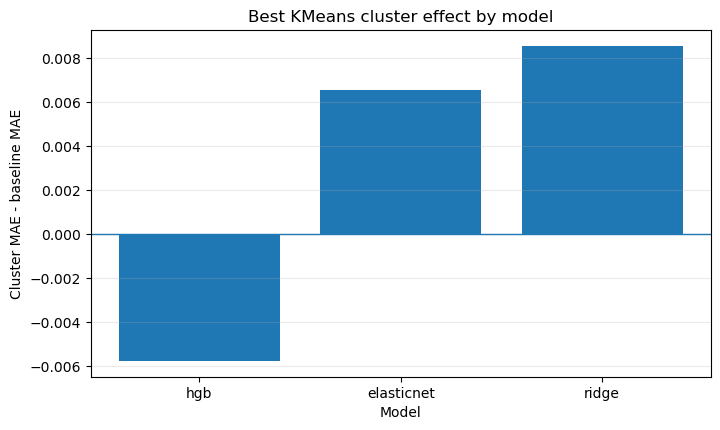

In [16]:
# Visualize the best cluster change for each model.
# Negative values mean clustering improved MAE.

plot_data = best_cluster.sort_values("delta_mae")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    plot_data["model"],
    plot_data["delta_mae"],
)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Cluster MAE - baseline MAE")
ax.set_xlabel("Model")
ax.set_title("Best KMeans cluster effect by model")
ax.grid(axis="y", alpha=0.25)
plt.show()

## 9. Decision guide

Use the results above to make the decision in human terms.

### Keep cluster features when

- mean MAE improves by a useful amount;
- the improvement is not coming from only one fold;
- the result is reasonably stable;
- the extra complexity is justified by the gain.

### Reject cluster features when

- MAE is unchanged or worse;
- the improvement is extremely small compared with fold variation;
- only one fold drives the improvement;
- the model already captures the same information without the cluster representation.

### Human note

KMeans is not automatically valuable because it creates sophisticated-looking features. It only earns a place in the final pipeline if the validation results show that the distances contain information the shortlisted model was not already using.

In [17]:
print("CLUSTER EXPERIMENT SUMMARY\n")

for _, row in summary.sort_values("best_mae").iterrows():
    print(
        f"{row['model']:14s} | "
        f"best overall: {row['best_variant']:10s} | "
        f"MAE {row['best_mae']:.4f}"
    )

    if row["best_variant"] == "baseline":
        print(
            "  Decision signal: the original 03 configuration "
            "still performs best."
        )
    else:
        best_cluster_row = best_cluster[
            best_cluster["model"] == row["model"]
        ].iloc[0]

        print(
            f"  Best cluster change: "
            f"{best_cluster_row['delta_mae']:+.4f} MAE; "
            f"{int(best_cluster_row['folds_improved'])}/{N_SPLITS} "
            "folds improved."
        )

    print()

CLUSTER EXPERIMENT SUMMARY

elasticnet     | best overall: baseline   | MAE 2.7278
  Decision signal: the original 03 configuration still performs best.

ridge          | best overall: baseline   | MAE 2.7293
  Decision signal: the original 03 configuration still performs best.

hgb            | best overall: cluster_k4 | MAE 3.0644
  Best cluster change: -0.0058 MAE; 4/5 folds improved.



## 10. Observation, Decision & Reasoning

### Observation: 

Cluster-distance features did not improve the two strongest models. ElasticNet increased from 2.7278 MAE to 2.7344–2.7351, while Ridge increased from 2.7293 to 2.7379–2.7428. HGB showed a small improvement with K=4, from 3.0702 to 3.0644, with improvement in four of five folds.

### Decision: 

Do not carry KMeans cluster features into the main final-model pipeline.

### Reasoning: 

The strongest Ridge and ElasticNet configurations already contain the continuous baseball measures from which the clusters are derived, so the cluster distances appear largely redundant. Although HGB benefits slightly from K=4, the improvement is only about 0.006 MAE and HGB remains substantially weaker than the leading linear models. The small gain does not justify the additional clustering complexity.
